In [131]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import KNNImputer, SimpleImputer, IterativeImputer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
import regex as re

In [132]:
df=pd.read_csv('smoking-v1.csv')
df.head()

,gender,age,marital_status,highest_qualification,nationality,ethnicity,gross_income,region,smoke,amt_weekends,amt_weekdays,type
0,Male,38.0,Divorced,No Qualification,British,White,"2,600 to 5,200",The North,No,NaN,NaN,NaN
1,Female,42.0,Single,No Qualification,British,White,"Under 2,600",The North,Yes,12.0,12.0,Packets
2,Male,40.0,Married,Degree,English,White,"28,600 to 36,400",The North,No,NaN,NaN,NaN
3,Female,NaN,Married,Degree,English,White,"10,400 to 15,600",The North,No,NaN,NaN,NaN
4,Female,39.0,Married,GCSE/O Level,British,White,"2,600 to 5,200",The North,No,NaN,NaN,NaN


In [133]:
df['highest_qualification'].value_counts()

highest_qualification
No Qualification     586
GCSE/O Level         308
Degree               262
Other/Sub Degree     127
Higher/Sub Degree    125
A Levels             105
GCSE/CSE             102
ONC/BTEC              76
Name: count, dtype: int64

In [134]:
df['ethnicity'].value_counts()

ethnicity
White      1560
Asian        41
Black        34
Chinese      27
Mixed        14
Refused      13
Unknown       2
Name: count, dtype: int64

In [135]:
df.isnull().sum()

gender                      0
age                        98
marital_status              0
highest_qualification       0
nationality                 0
ethnicity                   0
gross_income               75
region                      0
smoke                       0
amt_weekends             1270
amt_weekdays             1270
type                     1270
dtype: int64

In [136]:
df['type'].value_counts()

type
Packets                    297
Hand-Rolled                 72
Both/Mainly Packets         42
Both/Mainly Hand-Rolled     10
Name: count, dtype: int64

In [137]:
len(df)

1691

In [138]:
df.drop(columns=['type'],inplace=True)

In [139]:
ctr=0
for _,row in df.iterrows():
    if (pd.isna(row['amt_weekends']) or pd.isna(row['amt_weekdays'])) and row['smoke']=='Yes':
        ctr+=1
ctr

0

In [140]:
simple_imputer=SimpleImputer(strategy='constant',fill_value=0)

In [141]:
df['amt_weekdays']=df['amt_weekdays'].fillna(0)

In [142]:
df.head()

,gender,age,marital_status,highest_qualification,nationality,ethnicity,gross_income,region,smoke,amt_weekends,amt_weekdays
0,Male,38.0,Divorced,No Qualification,British,White,"2,600 to 5,200",The North,No,NaN,0.0
1,Female,42.0,Single,No Qualification,British,White,"Under 2,600",The North,Yes,12.0,12.0
2,Male,40.0,Married,Degree,English,White,"28,600 to 36,400",The North,No,NaN,0.0
3,Female,NaN,Married,Degree,English,White,"10,400 to 15,600",The North,No,NaN,0.0
4,Female,39.0,Married,GCSE/O Level,British,White,"2,600 to 5,200",The North,No,NaN,0.0


In [143]:
df['amt_weekends']=df['amt_weekends'].fillna(0)

In [144]:
df.isnull().sum()

gender                    0
age                      98
marital_status            0
highest_qualification     0
nationality               0
ethnicity                 0
gross_income             75
region                    0
smoke                     0
amt_weekends              0
amt_weekdays              0
dtype: int64

<Axes: >

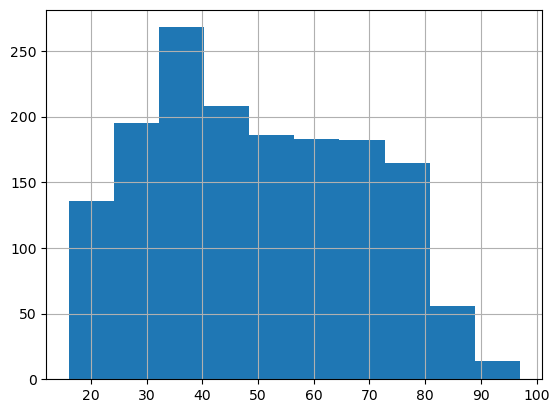

In [145]:
df['age'].hist()

In [146]:
df['age']=df['age'].fillna(df['age'].median())

In [147]:
df.isnull().sum()

gender                    0
age                       0
marital_status            0
highest_qualification     0
nationality               0
ethnicity                 0
gross_income             75
region                    0
smoke                     0
amt_weekends              0
amt_weekdays              0
dtype: int64

In [148]:
len(df['gross_income'].unique())

11

In [149]:
len(df['nationality'].unique())

8

In [150]:
df['region'].value_counts()

region
Midlands & East Anglia    443
The North                 426
South East                252
London                    182
South West                157
Scotland                  148
Wales                      83
Name: count, dtype: int64

In [151]:
df['ethnicity'].value_counts()

ethnicity
White      1560
Asian        41
Black        34
Chinese      27
Mixed        14
Refused      13
Unknown       2
Name: count, dtype: int64

In [152]:
df.drop(columns=['ethnicity'],inplace=True)

In [153]:
df.head()

,gender,age,marital_status,highest_qualification,nationality,gross_income,region,smoke,amt_weekends,amt_weekdays
0,Male,38.0,Divorced,No Qualification,British,"2,600 to 5,200",The North,No,0.0,0.0
1,Female,42.0,Single,No Qualification,British,"Under 2,600",The North,Yes,12.0,12.0
2,Male,40.0,Married,Degree,English,"28,600 to 36,400",The North,No,0.0,0.0
3,Female,48.0,Married,Degree,English,"10,400 to 15,600",The North,No,0.0,0.0
4,Female,39.0,Married,GCSE/O Level,British,"2,600 to 5,200",The North,No,0.0,0.0


In [154]:
df['gross_income'].value_counts()

gross_income
5,200 to 10,400     377
10,400 to 15,600    257
2,600 to 5,200      245
15,600 to 20,800    179
20,800 to 28,600    147
Under 2,600         126
Refused             104
Above 36,400         88
28,600 to 36,400     75
Unknown              18
Name: count, dtype: int64

In [155]:
def preprocess_income(value):
    if not pd.isna(value):
        value=value.replace(",","")
        print(re.findall(r"\d+",value))

In [156]:
preprocess_income("Under 2,600")

['2600']


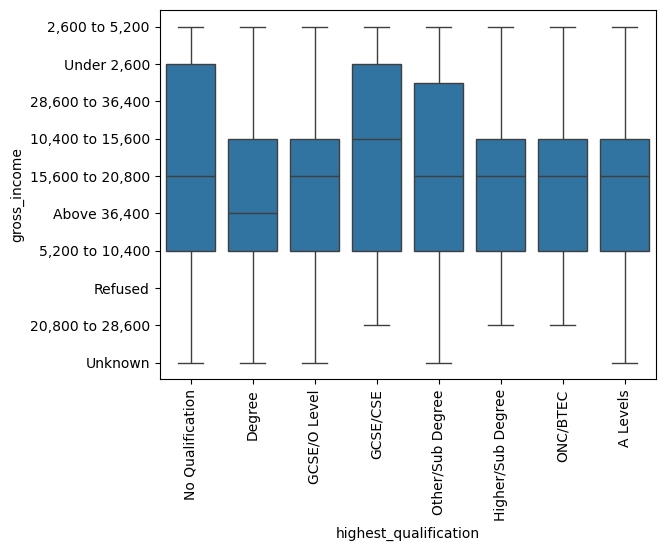

In [157]:
import matplotlib.pyplot as plt
sns.boxplot(x='highest_qualification',y='gross_income',data=df)
plt.xticks(rotation=90)
plt.show()

In [158]:
grouped_data = df.groupby(by=['highest_qualification', 'gross_income']).size().reset_index(name='count')
grouped_data

,highest_qualification,gross_income,count
0,A Levels,"10,400 to 15,600",23
1,A Levels,"15,600 to 20,800",19
2,A Levels,"2,600 to 5,200",8
3,A Levels,"20,800 to 28,600",7
4,A Levels,"28,600 to 36,400",5
...,...,...,...
72,Other/Sub Degree,"5,200 to 10,400",41
73,Other/Sub Degree,"Above 36,400",1
74,Other/Sub Degree,Refused,8
75,Other/Sub Degree,"Under 2,600",6


In [159]:
# df['gross_income']=df['gross_income'].replace(['Refused','Unknown'],np.nan)

In [160]:
df.isnull().sum()

gender                    0
age                       0
marital_status            0
highest_qualification     0
nationality               0
gross_income             75
region                    0
smoke                     0
amt_weekends              0
amt_weekdays              0
dtype: int64

In [161]:
categories=["Under 2,600","2,600 to 5,200","5,200 to 10,400","10,400 to 15,600","15,600 to 20,800","20,800 to 28,600","28,600 to 36,400","Above 36,400 "]

In [162]:
# ordinal_encoder=OrdinalEncoder(categories=[categories],handle_unknown='use_encoded_value',unknown_value=np.nan)

In [163]:
# df[['gross_income']]=ordinal_encoder.fit_transform(df[['gross_income']])

In [164]:
df.head()

,gender,age,marital_status,highest_qualification,nationality,gross_income,region,smoke,amt_weekends,amt_weekdays
0,Male,38.0,Divorced,No Qualification,British,"2,600 to 5,200",The North,No,0.0,0.0
1,Female,42.0,Single,No Qualification,British,"Under 2,600",The North,Yes,12.0,12.0
2,Male,40.0,Married,Degree,English,"28,600 to 36,400",The North,No,0.0,0.0
3,Female,48.0,Married,Degree,English,"10,400 to 15,600",The North,No,0.0,0.0
4,Female,39.0,Married,GCSE/O Level,British,"2,600 to 5,200",The North,No,0.0,0.0


In [165]:
df['marital_status'].value_counts()

marital_status
Married      812
Single       427
Widowed      223
Divorced     161
Separated     68
Name: count, dtype: int64

In [166]:
df['highest_qualification'].value_counts()

highest_qualification
No Qualification     586
GCSE/O Level         308
Degree               262
Other/Sub Degree     127
Higher/Sub Degree    125
A Levels             105
GCSE/CSE             102
ONC/BTEC              76
Name: count, dtype: int64

In [167]:
education_map = {
    'No Qualification': 0,
    'GCSE/CSE': 1,
    'GCSE/O Level': 2,
    'ONC/BTEC': 3,
    'A Levels': 4,
    'Other/Sub Degree': 5,
    'Higher/Sub Degree': 5, 
    'Degree': 6
}

df['highest_qualification'] = df['highest_qualification'].map(education_map)

In [168]:
df.head()

,gender,age,marital_status,highest_qualification,nationality,gross_income,region,smoke,amt_weekends,amt_weekdays
0,Male,38.0,Divorced,0,British,"2,600 to 5,200",The North,No,0.0,0.0
1,Female,42.0,Single,0,British,"Under 2,600",The North,Yes,12.0,12.0
2,Male,40.0,Married,6,English,"28,600 to 36,400",The North,No,0.0,0.0
3,Female,48.0,Married,6,English,"10,400 to 15,600",The North,No,0.0,0.0
4,Female,39.0,Married,2,British,"2,600 to 5,200",The North,No,0.0,0.0


In [169]:
df=df[df['gross_income']!='Refused']

In [170]:
df['gross_income'].unique()

array(['2,600 to 5,200', 'Under 2,600', '28,600 to 36,400',
       '10,400 to 15,600', '15,600 to 20,800', 'Above 36,400',
       '5,200 to 10,400', '20,800 to 28,600', 'Unknown', nan],
      dtype=object)

In [171]:
df['gross_income']=df['gross_income'].replace(['Refused','Unknown'],np.nan)

In [172]:
df.head()

,gender,age,marital_status,highest_qualification,nationality,gross_income,region,smoke,amt_weekends,amt_weekdays
0,Male,38.0,Divorced,0,British,"2,600 to 5,200",The North,No,0.0,0.0
1,Female,42.0,Single,0,British,"Under 2,600",The North,Yes,12.0,12.0
2,Male,40.0,Married,6,English,"28,600 to 36,400",The North,No,0.0,0.0
3,Female,48.0,Married,6,English,"10,400 to 15,600",The North,No,0.0,0.0
4,Female,39.0,Married,2,British,"2,600 to 5,200",The North,No,0.0,0.0


In [173]:
categories=["Under 2,600","2,600 to 5,200","5,200 to 10,400","10,400 to 15,600","15,600 to 20,800","20,800 to 28,600","28,600 to 36,400","Above 36,400 "]

In [174]:
 ordinal_encoder=OrdinalEncoder(categories=[categories],handle_unknown='use_encoded_value',unknown_value=np.nan)

In [175]:
df[['gross_income']]=ordinal_encoder.fit_transform(df[['gross_income']])

<Axes: >

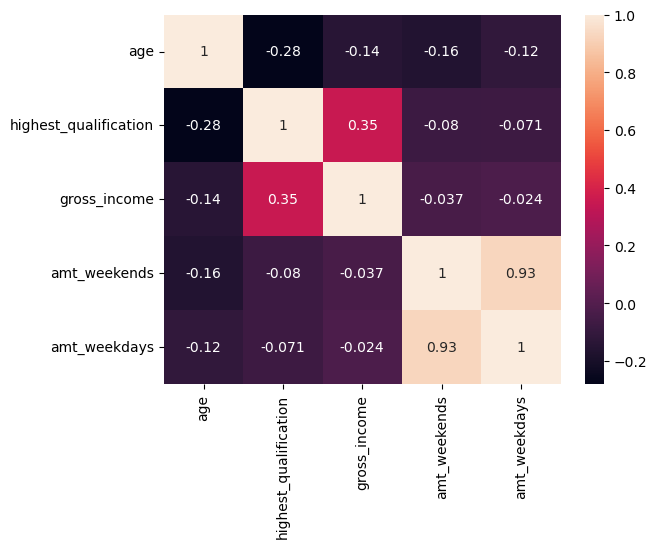

In [176]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [177]:
df.isnull().sum()

gender                     0
age                        0
marital_status             0
highest_qualification      0
nationality                0
gross_income             181
region                     0
smoke                      0
amt_weekends               0
amt_weekdays               0
dtype: int64

In [178]:
# iterative_imputer = IterativeImputer()
# imputed_data = iterative_imputer.fit_transform(df[["VRDeck", "FoodCourt", "Spa"]])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1587 entries, 0 to 1690
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   gender                 1587 non-null   object 
 1   age                    1587 non-null   float64
 2   marital_status         1587 non-null   object 
 3   highest_qualification  1587 non-null   int64  
 4   nationality            1587 non-null   object 
 5   gross_income           1406 non-null   float64
 6   region                 1587 non-null   object 
 7   smoke                  1587 non-null   object 
 8   amt_weekends           1587 non-null   float64
 9   amt_weekdays           1587 non-null   float64
dtypes: float64(4), int64(1), object(5)
memory usage: 136.4+ KB


In [179]:
df['gender']=df['gender'].map({"Male":1,"Female":0})

In [180]:
df['gender'].value_counts()

gender
0    904
1    683
Name: count, dtype: int64

In [181]:
label_encoder=LabelEncoder()
df['marital_status']=label_encoder.fit_transform(df['marital_status'])

In [182]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1587 entries, 0 to 1690
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   gender                 1587 non-null   int64  
 1   age                    1587 non-null   float64
 2   marital_status         1587 non-null   int64  
 3   highest_qualification  1587 non-null   int64  
 4   nationality            1587 non-null   object 
 5   gross_income           1406 non-null   float64
 6   region                 1587 non-null   object 
 7   smoke                  1587 non-null   object 
 8   amt_weekends           1587 non-null   float64
 9   amt_weekdays           1587 non-null   float64
dtypes: float64(4), int64(3), object(3)
memory usage: 136.4+ KB


In [183]:
df['nationality']=label_encoder.fit_transform(df['nationality'])

In [184]:
df['region']=label_encoder.fit_transform(df['region'])

In [185]:
df['smoke']=df['smoke'].map({"Yes":1,"No":0})

In [186]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1587 entries, 0 to 1690
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   gender                 1587 non-null   int64  
 1   age                    1587 non-null   float64
 2   marital_status         1587 non-null   int64  
 3   highest_qualification  1587 non-null   int64  
 4   nationality            1587 non-null   int64  
 5   gross_income           1406 non-null   float64
 6   region                 1587 non-null   int64  
 7   smoke                  1587 non-null   int64  
 8   amt_weekends           1587 non-null   float64
 9   amt_weekdays           1587 non-null   float64
dtypes: float64(4), int64(6)
memory usage: 136.4 KB


In [192]:
iterative_imputer = IterativeImputer()
imputed_data = iterative_imputer.fit_transform(df)
df_imputed = pd.DataFrame(imputed_data, columns=df.columns, index=df.index)

In [193]:
df_imputed.head()

,gender,age,marital_status,highest_qualification,nationality,gross_income,region,smoke,amt_weekends,amt_weekdays
0,1.0,38.0,0.0,0.0,0.0,1.0,5.0,0.0,0.0,0.0
1,0.0,42.0,3.0,0.0,0.0,0.0,5.0,1.0,12.0,12.0
2,1.0,40.0,1.0,6.0,1.0,6.0,5.0,0.0,0.0,0.0
3,0.0,48.0,1.0,6.0,1.0,3.0,5.0,0.0,0.0,0.0
4,0.0,39.0,1.0,2.0,0.0,1.0,5.0,0.0,0.0,0.0


In [194]:
df=df_imputed

In [195]:
df.isnull().sum()

gender                   0
age                      0
marital_status           0
highest_qualification    0
nationality              0
gross_income             0
region                   0
smoke                    0
amt_weekends             0
amt_weekdays             0
dtype: int64

In [212]:
X, y = df.drop(columns=["smoke"]), df["smoke"]

In [213]:
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.2)

In [214]:
classifier = DecisionTreeClassifier().fit(train_X, train_y)

In [215]:
pred_y=classifier.predict(test_X)

In [216]:
print(classification_report(test_y, pred_y))

              precision    recall  f1-score   support

         0.0       0.56      0.58      0.57        86
         1.0       0.56      0.54      0.55        85

    accuracy                           0.56       171
   macro avg       0.56      0.56      0.56       171
weighted avg       0.56      0.56      0.56       171



In [202]:
df.drop(columns=['amt_weekends','amt_weekdays'],inplace=True)

In [208]:
df['smoke'].value_counts()

smoke
0.0    1186
1.0     401
Name: count, dtype: int64

In [210]:
target0 = df[df['smoke'] == 0].sample(450)
target1 = df[df['smoke'] == 1]

In [211]:
new_df = pd.concat([target0, target1], ignore_index=True)
df = new_df.sample(len(new_df))